# 🧪 Experiment EIMR_040 — Order MILP CFA vs Baseline

## 📝 Introduction

In this experiment, we investigate how the candidate policy `OrderMilpCfaPolicy` behaves in an inventory system with multi regime Poisson demand. To assess its value, we compare it against the baseline heuristic `OrderUpToPolicy`.

Beyond overall performance, we also examine how different parameterizations or optimization variants of `OrderMilpCfaPolicy` affect the results.

This leads to the following guiding questions:

- ***RQ1*** – Can a `OrderMilpCfaPolicy` policy outperform the simple fixed baseline heuristic `OrderUpToPolicy`?
- ***RQ2*** – How sensitive is the policy’s performance to the chosen forecasting method?

To answer these questions, we follow our standard analytical workflow: define the problem, specify the candidate policies and their variants, evaluate them under **strict CRN**, and compare the results systematically.

If useful, you may extend the analysis by:
- using **Appendix C: Statistical Analysis** for a deeper comparison of two policies, or
- using **Appendix A** to visualize the system dynamics induced by a policy.

We conclude by summarizing the main findings, answering the research questions, and extracting an **exam-relevant takeaway**.

---

**Notes**

- The implementation `OrderMilpCfaPolicy` in `cfa.py` and its descriptive companion document `cfa.md` can be found in `src/inventory/policies/`.
- Repository conventions are documented in [concepts/00_repo_conventions.ipynb](../../../concepts/00_repo_conventions.ipynb).
- If you have trouble running this notebook, first verify your environment in [lectures/00_setup.ipynb](../../../lectures/00_setup.ipynb).

## 📦 Imports

Here we define all required imports to conduct our experiment.

In [1]:
# Imports

import numpy as np



# Optional: in-notebook sanity check (no-op when installed)

from inventory.evaluation.notebooks.bootstrap import ensure_inventory_imports

ensure_inventory_imports(verbose=False)



# Evaluation

from inventory.evaluation import make_eval_info

from inventory.evaluation.reporting import summarize_totals



# Plotting

from inventory.evaluation.plotting import plot_multi_regime_sample_path



# Dynamic system framework

from inventory.core.dynamics import DynamicSystem



# Problem definitions

from inventory.problems.inventory_mvp import inventory_cost, inventory_cost_extended, inventory_transition



# Demand model (exogenous)

from inventory.problems.demand_models import ExogenousPoissonMultiRegime



# Forecaster

from inventory.forecasters.ml import MlRegimeDemandForecaster, MultiRegimeFeatureAdapter

from inventory.forecasters.ml import MlAr1RegimeDemandForecaster, MultiRegimeAr1FeatureAdapter

from inventory.forecasters.ml import QuantileBoostingRegimeDemandForecaster

from inventory.forecasters.ts import EtsDemandForecaster, SarimaxRegimeDemandForecaster

from inventory.forecasters.naive import ConstantMeanForecaster, NaiveForecaster, RollingMeanForecaster



# Policies

from inventory.policies.baselines import OrderUpToPolicy

from inventory.policies.cfa_milp import OrderMilpCfaPolicy

---

## 🚧 Problem definition

In this experiment we use our benchmark inventory problem with multi-regime Poisson demand and our standard set of cost parameters. Keeping this problem definition constant across experiments enables us to compare the effects of different policies while allowing demand intensity to vary with season, day, and weather.

In [2]:
# === Defining the dynamic system ===

# Simulation horizon
T = 30

# Initial Inventory
# Start in (inventory=300, season=Summer=2, day=Monday=0, weather=Sunny=2)
S0= np.array([300.0, 2.0, 0.0, 2.0], dtype=float)

# Constraints
x_max = 480
dx = 10
S_max = 480

# Exogenous demand
exo = ExogenousPoissonMultiRegime(season_index=1, day_index=2, weather_index=3, season_period=90)

# Cost parameters 
p, c, h, b, K = 2.0, 0.5, 0.03, 1.0, 50.0

# Transition function
transition_func = inventory_transition

# Cost functions
cost_func = lambda s, a, w, t: inventory_cost(s, a, w, t, p=p, c=c, h=h, b=b)
cost_func = lambda s, a, w, t: inventory_cost_extended(s, a, w, t, p=p, c=c, h=h, b=b, K=K)

# Dynamic System
system = DynamicSystem(
    transition_func=transition_func,
    cost_func=cost_func,
    exogenous_model=exo,
    sim_seed=42,
    d_s=4,
    d_x=1,
    d_w=4,
    demand_history_window=3,
 )

# Strict-CRN Monte Carlo evaluation settings
seed0 = 1234
n_episodes = 200
eval_info = make_eval_info(T=T, det_mode='argmax')
eval_info

{'deterministic': True, 'det_mode': 'argmax', 'T': 30}

To get an idea about the kind of demand pattern we are dealing with in this problem setting, let us have a lookt at one expamplary demand that matches the CRN “reference episode” seed stream.

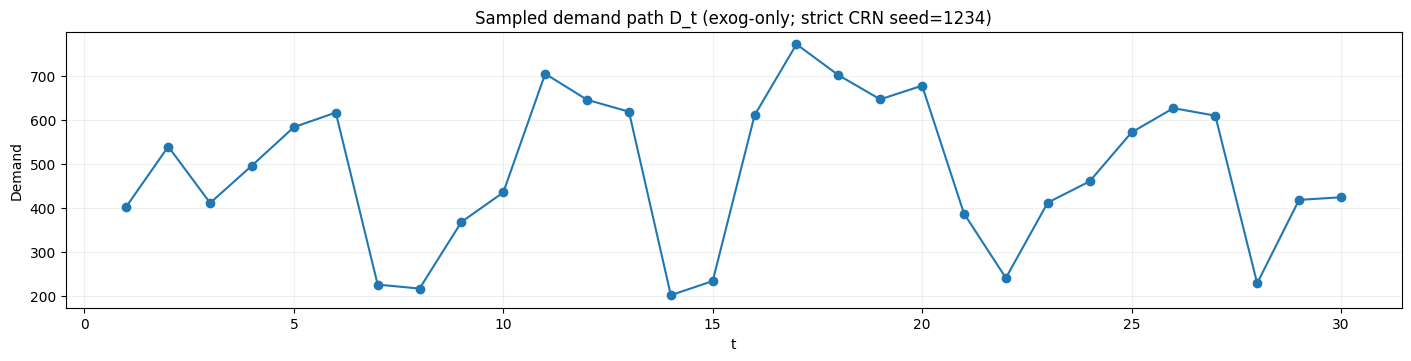

In [3]:
_ = plot_multi_regime_sample_path(exo,T, seed0, state0=S0, figsize=(14, 3.5), demand_only=True)

---

## 🔮 Forecaster defintion



In this section, we specify which information model (a.k.a. **forecaster**) the policy uses to anticipate future demand in the multi-regime setting. We instantiate regime-aware forecaster variants, including a naive forecaster that repeats the last observed demand, a constant-mean forecaster that freezes the current regime-implied demand mean, and a learned ML forecaster trained on synthetic data from the same exogenous model.

Next, we conclude with a short sanity check to ensure that the resulting predictions are reasonable before they are embedded into the policy.

In [3]:
# === Naive Forecaster ===
# Naive forecaster: repeat the last observed demand for the next H steps.
# For the initial fallback, use the effective Poisson mean implied by the current multi-regime state.
mu0_multi_regime = exo.lambda_for_regimes(
    int(S0[exo.season_index]),
    int(S0[exo.day_index]),
    int(S0[exo.weather_index]),
)
forecaster_naive = NaiveForecaster(default_value=float(mu0_multi_regime))

# Print example prediction: Planned info payload passed into the CFA policy / forecaster call
naive_info_demo = {"last_demand": [295.0]}
H_demo = 5
mu_demo_naive = forecaster_naive.forecast_mean_path(S0, t=0, H=H_demo, info=naive_info_demo)
print("mu0_multi_regime:", float(mu0_multi_regime))
print("naive_info_demo:", naive_info_demo)
print(f"mu_demo_naive (H={H_demo}):", np.round(mu_demo_naive, 2))

mu0_multi_regime: 582.0
naive_info_demo: {'last_demand': [295.0]}
mu_demo_naive (H=5): [295. 295. 295. 295. 295.]


In [5]:
# === Constant Forecaster ===
# Constant-mean forecaster: freeze the current regime-implied demand mean across the horizon.
forecaster_const = ConstantMeanForecaster(mean=float(350.0))

# Print example prediction: forecast mean demand path
H_demo = 5
mu_demo_const = forecaster_const.forecast_mean_path(S0, t=0, H=H_demo)
print(f"mu_demo_const (H={H_demo}):", np.round(mu_demo_const, 2))

mu_demo_const (H=5): [350. 350. 350. 350. 350.]


In [6]:
# === Rolling Mean Forecaster ===

# Rolling-mean forecaster: predict the mean of the last n observed demand values as next demand.
# During rollout, the simulator now provides a bounded demand_history when demand_history_window > 0.
forecaster_roll = RollingMeanForecaster(window_size=3, default_value=float(mu0_multi_regime))

# Print example prediction: forecast mean demand path
rolling_info_demo = {"demand_history": [300.0, 340.0, 365.0, 355.0]}
mu_demo_roll = forecaster_roll.forecast_mean_path(S0, t=0, H=H_demo, info=rolling_info_demo)
print("rolling history:", rolling_info_demo["demand_history"])
print("rolling-mean forecast:", mu_demo_roll)


rolling history: [300.0, 340.0, 365.0, 355.0]
rolling-mean forecast: [353.33333333 353.33333333 353.33333333 353.33333333 353.33333333]


In [7]:
# === ML Forecaster ===
# Use the regime-aware adapter and forecaster so the model can condition on season, day, and weather.
adapter = MultiRegimeFeatureAdapter(exo)
forecaster_ml = MlRegimeDemandForecaster(adapter, model_type="tree", random_state=0)

# Train on synthetic data generated from the multi-regime exogenous model
fit_seed = 7
val_seed = 99

forecaster_ml.fit_from_exogenous(
    n_samples=6000,
    seed=fit_seed,
    t_start=0,
    val_samples=1000,
    val_seed=val_seed,
    val_t_start=8000,
 )

# Print ML forecaster fit report summary
print("ML forecaster fit_report (summary):")
print("  model_type:", forecaster_ml.fit_report.get("model_type"))
print("  feature_dim:", forecaster_ml.fit_report.get("feature_dim"))
for split in ("train", "val"):
    rep = forecaster_ml.fit_report.get(split, {})
    mae = rep.get("MAE")
    rmse = rep.get("RMSE")
    bias = rep.get("Bias")
    n = rep.get("n_samples")
    print(f"  {split}: n={n} | MAE={mae:.3f} | RMSE={rmse:.3f} | Bias={bias:.3f}")

# Print example prediction: forecast mean demand path for the current multi-regime state
H_demo = 5
mu_demo = forecaster_ml.forecast_mean_path(S0, t=0, H=H_demo)
print(f"\nmu_demo (H={H_demo}):", np.round(mu_demo, 2))

ML forecaster fit_report (summary):
  model_type: tree
  feature_dim: 15
  train: n=6000 | MAE=63.400 | RMSE=82.902 | Bias=-0.000
  val: n=1000 | MAE=65.455 | RMSE=85.690 | Bias=1.988

mu_demo (H=5): [473.96 693.02 598.78 598.78 704.08]


In [8]:
# === ML Forecaster ===
# Use the regime-aware AR(1) adapter and forecaster so the model can condition on season, day, weather, and the most recent realized demand.
adapter = MultiRegimeAr1FeatureAdapter(exo, lag_scale=100.0)
forecaster_ml = MlAr1RegimeDemandForecaster(adapter, model_type="tree", random_state=0)

# Train on synthetic data generated from the multi-regime exogenous model
fit_seed = 7
val_seed = 99

forecaster_ml.fit_from_exogenous(
    n_samples=6000,
    seed=fit_seed,
    t_start=0,
    val_samples=1000,
    val_seed=val_seed,
    val_t_start=8000,
 )

# Print ML forecaster fit report summary
print("ML forecaster fit_report (summary):")
print("  model_type:", forecaster_ml.fit_report.get("model_type"))
print("  feature_dim:", forecaster_ml.fit_report.get("feature_dim"))
for split in ("train", "val"):
    rep = forecaster_ml.fit_report.get(split, {})
    mae = rep.get("MAE")
    rmse = rep.get("RMSE")
    bias = rep.get("Bias")
    n = rep.get("n_samples")
    print(f"  {split}: n={n} | MAE={mae:.3f} | RMSE={rmse:.3f} | Bias={bias:.3f}")

# Print example predictions: one default forecast and two forecasts conditioned on different last-demand shocks
H_demo = 5
mu_demo = forecaster_ml.forecast_mean_path(S0, t=0, H=H_demo)
mu_demo_low = forecaster_ml.forecast_mean_path(S0, t=0, H=H_demo, info={"last_demand": 150.0})
mu_demo_high = forecaster_ml.forecast_mean_path(S0, t=0, H=H_demo, info={"last_demand": 850.0})
print(f"\nmu_demo_default (H={H_demo}):", np.round(mu_demo, 2))
print(f"mu_demo_low_last_demand (H={H_demo}):", np.round(mu_demo_low, 2))
print(f"mu_demo_high_last_demand (H={H_demo}):", np.round(mu_demo_high, 2))

ML forecaster fit_report (summary):
  model_type: tree
  feature_dim: 16
  train: n=6000 | MAE=58.406 | RMSE=77.026 | Bias=0.000
  val: n=1000 | MAE=61.476 | RMSE=83.049 | Bias=3.297

mu_demo_default (H=5): [398.68 585.87 611.69 709.18 786.4 ]
mu_demo_low_last_demand (H=5): [397.   585.87 611.69 709.18 786.4 ]
mu_demo_high_last_demand (H=5): [508.93 709.18 671.85 786.4  786.4 ]


In [9]:
# === ML Forecaster ===
# Use the regime-aware adapter and forecaster so the model can condition on season, day, and weather.
adapter = MultiRegimeFeatureAdapter(exo)
forecaster_ml = MlRegimeDemandForecaster(adapter, model_type="elasticnet", random_state=0)

# Train on synthetic data generated from the multi-regime exogenous model
fit_seed = 7
val_seed = 99

forecaster_ml.fit_from_exogenous(
    n_samples=6000,
    seed=fit_seed,
    t_start=0,
    val_samples=1000,
    val_seed=val_seed,
    val_t_start=8000,
 )

# Print ML forecaster fit report summary
print("ML forecaster fit_report (summary):")
print("  model_type:", forecaster_ml.fit_report.get("model_type"))
print("  feature_dim:", forecaster_ml.fit_report.get("feature_dim"))
for split in ("train", "val"):
    rep = forecaster_ml.fit_report.get(split, {})
    mae = rep.get("MAE")
    rmse = rep.get("RMSE")
    bias = rep.get("Bias")
    n = rep.get("n_samples")
    print(f"  {split}: n={n} | MAE={mae:.3f} | RMSE={rmse:.3f} | Bias={bias:.3f}")

# Print example prediction: forecast mean demand path for the current multi-regime state
H_demo = 5
mu_demo = forecaster_ml.forecast_mean_path(S0, t=0, H=H_demo)
print(f"\nmu_demo (H={H_demo}):", np.round(mu_demo, 2))

ML forecaster fit_report (summary):
  model_type: elasticnet
  feature_dim: 15
  train: n=6000 | MAE=64.363 | RMSE=86.375 | Bias=0.000
  val: n=1000 | MAE=67.247 | RMSE=90.340 | Bias=1.138

mu_demo (H=5): [541.3  633.84 616.16 663.54 721.72]


In [ ]:
# === Quantile Boosting Forecaster ===
# Quantile boosting forecaster: fit gradient-boosted quantile trees on the regime features.
# This returns a targeted conditional demand quantile path rather than a mean path.

adapter = MultiRegimeFeatureAdapter(exo)
forecaster_qboost = QuantileBoostingRegimeDemandForecaster(
    adapter,
    quantile=0.75,
    random_state=0,
    n_estimators=120,
    learning_rate=0.05,
    max_depth=2,
)

# Train on synthetic data generated from the multi-regime exogenous model
fit_seed = 7
val_seed = 99

forecaster_qboost.fit_from_exogenous(
    n_samples=6000,
    seed=fit_seed,
    t_start=0,
    val_samples=1000,
    val_seed=val_seed,
    val_t_start=8000,
)

# Print ML forecaster fit report summary
print("Quantile boosting forecaster fit_report (summary):")
print("  model_type:", forecaster_qboost.fit_report.get("model_type"))
print("  quantile:", forecaster_qboost.fit_report.get("quantile"))
print("  feature_dim:", forecaster_qboost.fit_report.get("feature_dim"))

for split in ("train", "val"):
    rep = forecaster_qboost.fit_report.get(split, {})
    mae = rep.get("MAE")
    rmse = rep.get("RMSE")
    bias = rep.get("Bias")
    n = rep.get("n_samples")
    print(f"  {split}: n={n} | MAE={mae:.3f} | RMSE={rmse:.3f} | Bias={bias:.3f}")

# Print example prediction: forecast mean demand path for the current multi-regime state
H_demo = 5
mu_demo_qboost = forecaster_qboost.forecast_mean_path(S0, t=0, H=H_demo)
print(f"\nmu_demo_qboost_q75 (H={H_demo}):", np.round(mu_demo_qboost, 2))


Quantile boosting forecaster fit_report (summary):
  model_type: quantile_boosting
  quantile: 0.75
  feature_dim: 15
  train: n=6000 | MAE=74.897 | RMSE=99.217 | Bias=52.728
  val: n=1000 | MAE=76.982 | RMSE=103.462 | Bias=55.821

mu_demo_qboost_q75 (H=5): [598.5  746.03 704.8  718.35 805.76]


In [ ]:
# === ETS Forecaster ===
# ETS forecaster: fit a univariate exponential-smoothing model to a synthetic demand path.
# Unlike SARIMAX or the regime-aware ML forecasters, this is a pure time-series baseline and does not condition on the current regime state.

adapter = MultiRegimeFeatureAdapter(exo)
forecaster_ets = EtsDemandForecaster(
    adapter,
    trend="add",
    seasonal=None,
    damped_trend=True,
)

# Train on a synthetic demand path generated from the multi-regime exogenous model
fit_seed = 7
forecaster_ets.fit_from_exogenous(
    n_samples=1200,
    seed=fit_seed,
    t_start=0,
    val_samples=300,
)

# Print ETS forecaster fit report summary
print("ETS forecaster fit_report (summary):")
print("  model_type:", forecaster_ets.fit_report.get("model_type"))
print("  trend:", forecaster_ets.fit_report.get("trend"))
print("  seasonal:", forecaster_ets.fit_report.get("seasonal"))
print("  seasonal_periods:", forecaster_ets.fit_report.get("seasonal_periods"))
print("  damped_trend:", forecaster_ets.fit_report.get("damped_trend"))

for split in ("train", "val"):
    rep = forecaster_ets.fit_report.get(split, {})
    mae = rep.get("MAE")
    rmse = rep.get("RMSE")
    bias = rep.get("Bias")
    n = rep.get("n_samples")
    print(f"  {split}: n={n} | MAE={mae:.3f} | RMSE={rmse:.3f} | Bias={bias:.3f}")

# Print example prediction: forecast mean demand path for the next H steps
H_demo = 5
mu_demo_ets = forecaster_ets.forecast_mean_path(S0, t=0, H=H_demo)
print(f"\nmu_demo_ets (H={H_demo}):", np.round(mu_demo_ets, 2))


ETS forecaster fit_report (summary):
  model_type: ets
  trend: add
  seasonal: None
  seasonal_periods: None
  damped_trend: True
  train: n=1200 | MAE=107.876 | RMSE=143.398 | Bias=0.226
  val: n=300 | MAE=201.416 | RMSE=287.174 | Bias=-175.920

mu_demo_ets (H=5): [209.38 209.38 209.38 209.38 209.38]


In [ ]:
"""
That last result is informative: ETS is working technically, but in this multi-regime setting it is much less aligned with the problem structure than the regime-aware forecasters, so its forecasts collapse toward a smooth univariate baseline. That is exactly the kind of contrast Cell 23 is useful for showing.
"""

In [ ]:
# === SARIMAX Forecaster ===
# SARIMAX forecaster: fit an autoregressive model with exogenous regime features.
# This combines a linear time-series backbone with the regime-aware feature adapter.

adapter = MultiRegimeFeatureAdapter(exo)
forecaster_sarimax = SarimaxRegimeDemandForecaster(
    adapter,
    order=(1, 0, 0),
    seasonal_order=(0, 0, 0, 0),
    trend="c",
)



# Train on synthetic data generated from the multi-regime exogenous model
fit_seed = 7
val_seed = 99

forecaster_sarimax.fit_from_exogenous(
    n_samples=1200,
    seed=fit_seed,
    t_start=0,
    val_samples=300,
    val_seed=val_seed,
    val_t_start=1600,
)


# Print SARIMAX forecaster fit report summary
print("SARIMAX forecaster fit_report (summary):")
print("  model_type:", forecaster_sarimax.fit_report.get("model_type"))
print("  order:", forecaster_sarimax.fit_report.get("order"))
print("  seasonal_order:", forecaster_sarimax.fit_report.get("seasonal_order"))
print("  feature_dim:", forecaster_sarimax.fit_report.get("feature_dim"))
print("  aic:", forecaster_sarimax.fit_report.get("aic"))
print("  bic:", forecaster_sarimax.fit_report.get("bic"))

for split in ("train", "val"):
    rep = forecaster_sarimax.fit_report.get(split, {})
    mae = rep.get("MAE")
    rmse = rep.get("RMSE")
    bias = rep.get("Bias")
    n = rep.get("n_samples")
    print(f"  {split}: n={n} | MAE={mae:.3f} | RMSE={rmse:.3f} | Bias={bias:.3f}")

# Print example prediction: forecast mean demand path for the current multi-regime state
H_demo = 5
mu_demo_sarimax = forecaster_sarimax.forecast_mean_path(S0, t=0, H=H_demo)
print(f"\nmu_demo_sarimax (H={H_demo}):", np.round(mu_demo_sarimax, 2))


SARIMAX forecaster fit_report (summary):
  model_type: sarimax
  order: (1, 0, 0)
  seasonal_order: (0, 0, 0, 0)
  feature_dim: 15
  aic: 14131.113573398314
  bic: 14217.63070703378
  train: n=1200 | MAE=65.285 | RMSE=86.447 | Bias=-0.096
  val: n=300 | MAE=65.967 | RMSE=87.374 | Bias=-0.136

mu_demo_sarimax (H=5): [541.94 637.62 613.74 663.14 729.5 ]


---

## 🤖 Policy definition

In this section, we define the policies under investigation and collect them in a policy dictionary used by our strict-CRN evaluation pipeline.

The first policy is the canonical benchmark `OrderUpTo`. The second policy is the main candidate that we want to compare against this benchmark. The third policy is a controlled variation of the candidate, included to examine one targeted variation of interest.

This set of policies enables a structured comparison and helps us address our research questions.

In [10]:
# === Baseline Policy ===
# Baseline: a fixed order-up-to target
baseline = OrderUpToPolicy(target_level=350.0, x_max=x_max, dx=dx)


In [11]:
# === Candidate Policy ===
# Candidate: Calculate optimal order quantity from a certainty-equivalent MILP CFA with the constant-demand forecaster
candidate = OrderMilpCfaPolicy(
    forecaster=forecaster_naive,
    H=3,
    x_max=x_max,
    dx=dx,
    S_max=S_max,
    p=p,
    c=c,
    h=h,
    b=b,
    K=K,
 )


In [12]:
# === Controlled Variation of Candidate Policy ===
# Candidate Controlled Variation: same structure, but different forecaster (ML forecaster instead of naive forecaster)
candidate_var = OrderMilpCfaPolicy(
    forecaster=forecaster_ml,
    H=3,
    x_max=x_max,
    dx=dx,
    S_max=S_max,
    p=p,
    c=c,
    h=h,
    b=b,
    K=K,
 )

In [13]:
# === Collect policies into a dictionary for easy access in evaluation/reporting code ===
policies = {
    'baseline': baseline,
    'candidate': candidate,
    'candidate_var': candidate_var,
}

print('==== Policy Parameters ====')
policies

==== Policy Parameters ====


{'baseline': OrderUpToPolicy(target_level=350.0, x_max=480, dx=10),
 'candidate': OrderMilpCfaPolicy(H=3, x_max=480.0, dx=10, S_max=480.0, p=2.0, c=0.5, h=0.03, b=1.0, K=50.0, forecaster='NaiveForecaster'),
 'candidate_var': OrderMilpCfaPolicy(H=3, x_max=480.0, dx=10, S_max=480.0, p=2.0, c=0.5, h=0.03, b=1.0, K=50.0, forecaster='MlRegimeDemandForecaster')}

---

## 🪄 Experiment run and Strict-CRN policy evaluation

In this section, we evaluate all policies under identical sampled exogenous paths using strict CRN. This ensures a fair comparison and allows us to summarize and illustrate the resulting performance differences.

In [14]:
# === Experiment run and Strict-CRN policy evaluation ===
from inventory.evaluation.notebooks.crn_runs import run_crn_mc

run = run_crn_mc(
    system=system,
    policies=policies,
    S0=S0,
    T=T,
    n_episodes=n_episodes,
    seed0=seed0,
    info=eval_info,
    print_summary=True,
)

results = run.results
rollouts = run.rollouts
totals_by_policy = run.totals_by_policy
totals_summary = run.totals_summary

=== Final CRN-MC totals (lower is better) ===
baseline        | mean=-5852.780 | std=1001.492 | n=200 | runtime=0.266s
candidate       | mean=-12387.235 | std=908.770 | n=200 | runtime=6.710s
candidate_var   | mean=-13569.213 | std=773.030 | n=200 | runtime=5.274s


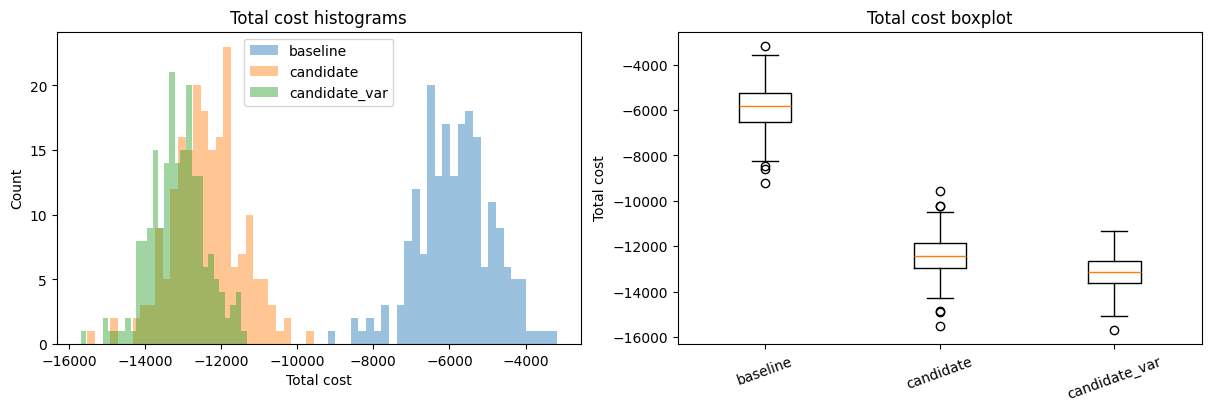

In [10]:
# === Plot total cost distribution and boxplot ===
from inventory.evaluation.plotting import plot_totals_hist_and_box
_ =plot_totals_hist_and_box(totals_by_policy)

## 🔬 Results, Insights & Discussion

In this section, we summarize and interpret the main findings of the experiment in a research-paper style. We first present the key results in compact form, using a result table and a main comparison plot to highlight overall performance differences.

We then discuss what these results teach us by interpreting the baseline–candidate comparison, the default–variation comparison within the candidate class, and their relevance for the underlying modeling question.

Based on this, we answer the research questions directly and conclude with implications and possible next steps.

### What are the main results?
- compact result table
- one main comparison plot
- short interpretation of who performs best
- ***Results 1***: 

### What do we learn?
- interpret baseline vs candidate
- interpret candidate default vs candidate variation
- connect result back to the modeling question
- ***Learning 1***: 

### How would we answer our reseach questions?
- ***RQ1***: 
- ***RQ2***: 

### What next steps would we plan?
- Address implications and next steps
- ***Next step1***:


---

## 🥊 Punchline

In this section, we distill the main punchline of the experiment into an exam-relevant takeaway. Think of it as the “if you remember only two things, remember these” message.


- ***Takeaway 1***: Lorem ipsum

- ***Takeaway 2***: Dolor sit 

---

# Appendix

## 🏎️ Appendix A: Dynamics of the system under policy regimes

In this section, we study the dynamics of the system under the different policy regimes. We first inspect one strict-CRN trajectory for all three policies to compare their actions and resulting system behavior. We then visualize many trajectories together with their mean paths to identify broader dynamic patterns.

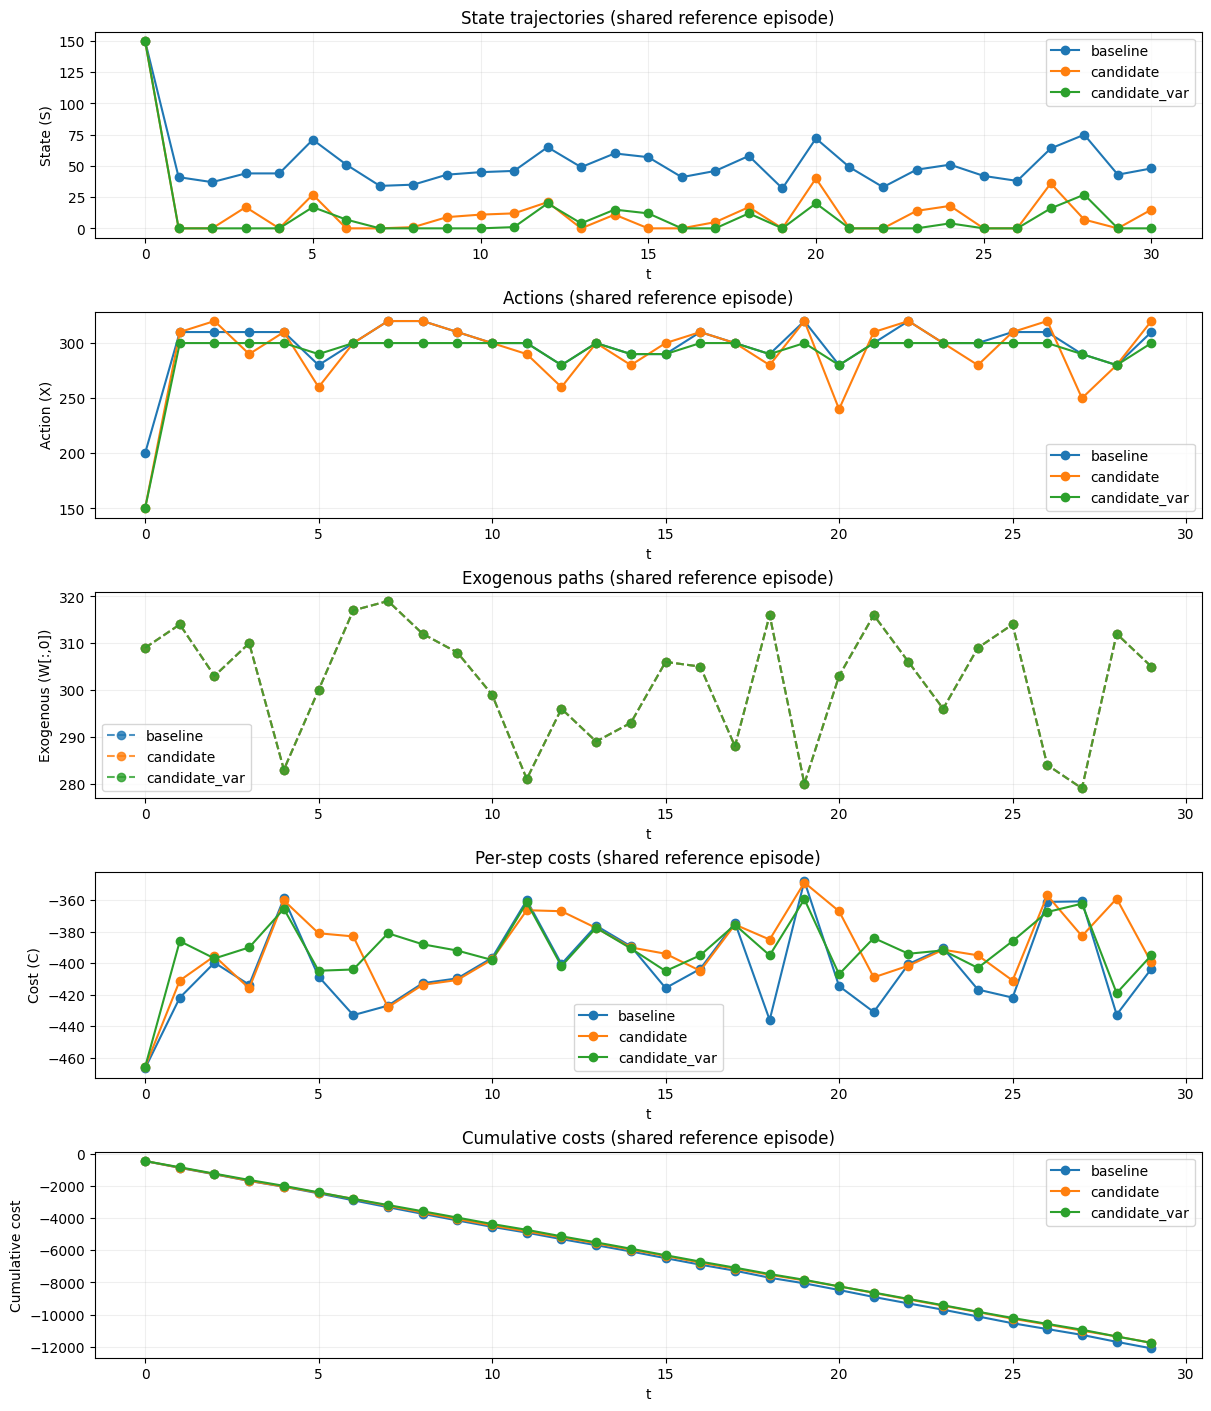

In [13]:
# === Visual dynamics for one shared *reference episode* per policy ===
from inventory.evaluation.plotting import plot_reference_episode_rollouts_grid
_ = plot_reference_episode_rollouts_grid(
    rollouts,
    figsize=(12, 14),
    show=True,
    marker="o",
 )

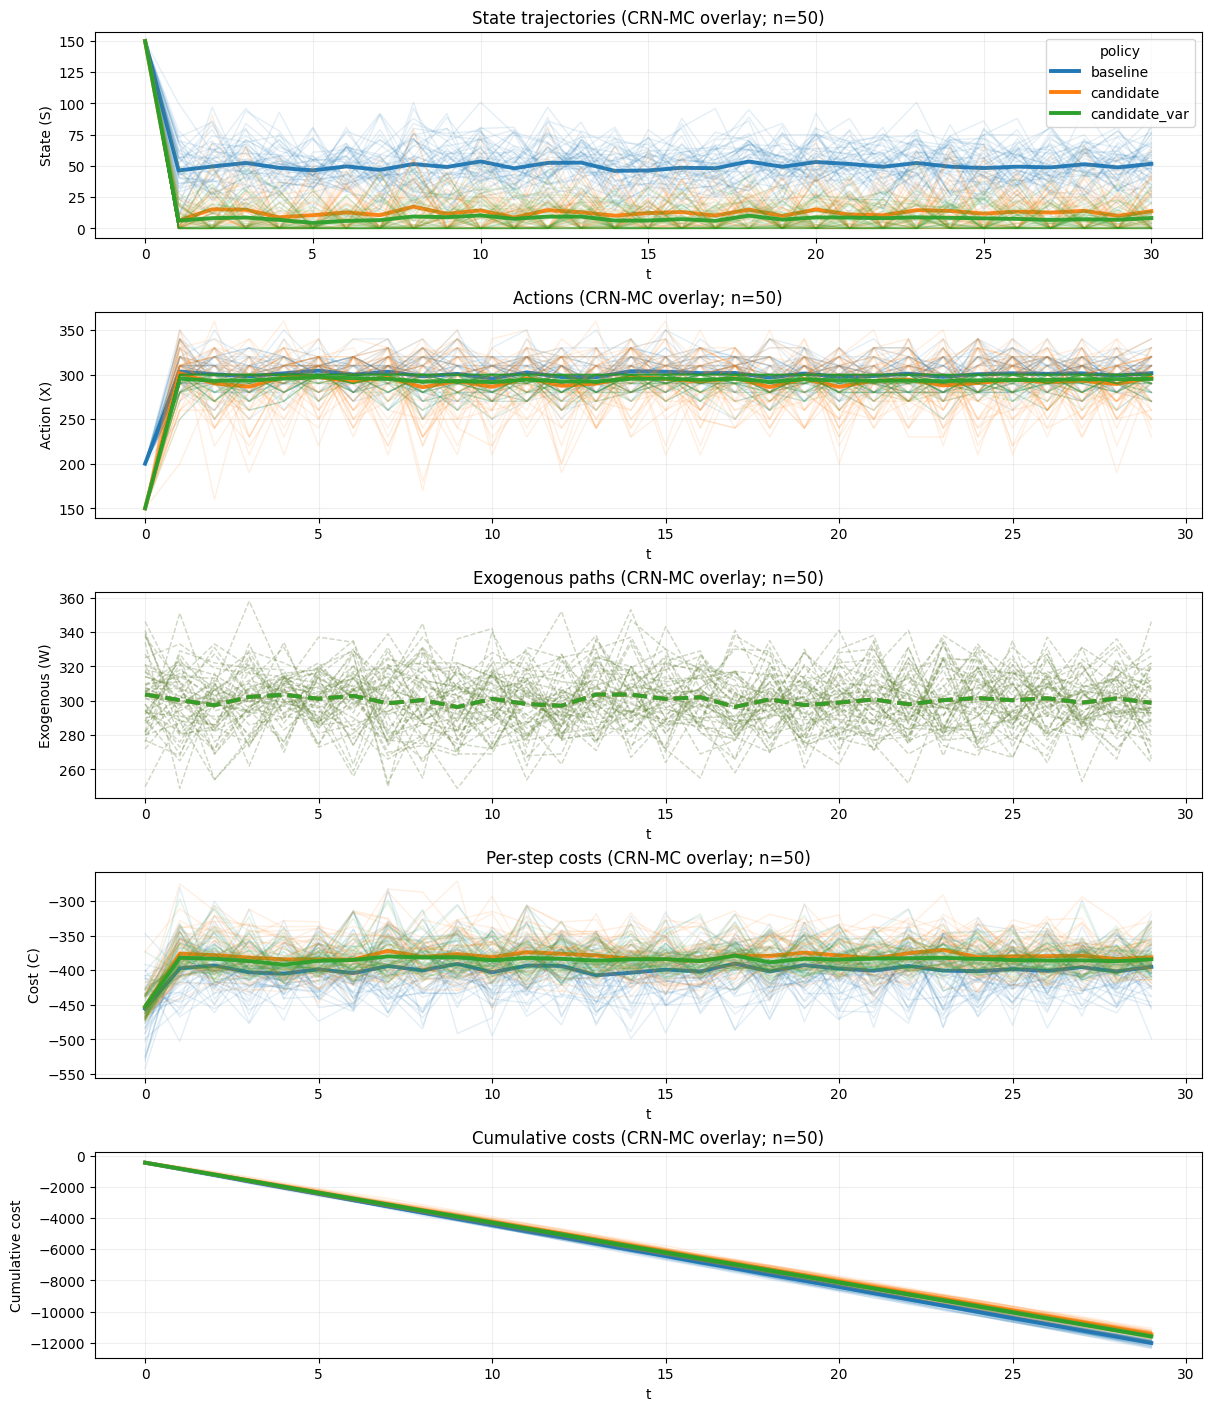

In [14]:
# === Visual dynamics across many episodes (overlay: faint lines = episodes, bold line = mean) ===

n_plot_episodes = 50

rollouts_mc = system.collect_policies_crn_rollouts_mc(
    policies,
    S0,
    T=T,
    n_episodes=n_plot_episodes,
    seed0=seed0,
    info=eval_info,
 )

from inventory.evaluation.plotting import plot_rollouts_overlay_grid
_ = plot_rollouts_overlay_grid(
    rollouts_mc,
    figsize=(12, 14),
    alpha_episode=0.12,
    linewidth_episode=1.0,
    linewidth_mean=2.8,
    title_suffix=f"(CRN-MC overlay; n={n_plot_episodes})",
    show=True,
 )

---

## 📈 Appendix B: Statistical validation

In this section, we statistically compare two policies in a rigorous and structured way. We begin by defining a baseline policy (the *control*) and a candidate policy (the *treatment*).

Given the hypothesis of interest, we define the paired-delta direction, compute the paired differences, and assess their normality. We then use these paired deltas to perform both a frequentist and a Bayesian hypothesis test.

Finally, we summarize the findings and interpret their meaning in context.

**Notes**

- This appendix supports the statistical comparison of **two** policies only. Multi-policy comparisons require different assumptions and a separate method, which is not implemented here.
- The frequentist and Bayesian hypotheses may differ slightly. They are stated explicitly in their respective sections.

### ⚖️ Paired Delta analysis

Our default hypothesis of interest is that the treatment policy has a positive effect, that is, it achieves a **lower total cost** than the control policy. We therefore compute the paired deltas in the corresponding direction and examine their distribution using a normality diagnostic. This prepares the ground for the subsequent frequentist and Bayesian analyses.


In [15]:
# === Get paired deltas summary ===
from inventory.evaluation.notebooks.reports import print_paired_delta_summary

reports = print_paired_delta_summary(
    totals_by_policy,
    baseline_name="baseline",
    higher_is_better=False,
)

=== Final CRN-MC PairedDeltaReport ===
baseline=baseline   | other=candidate  | mean_delta=533.167 | std_delta=116.472 | win_rate=0.000 | (lower is better)
baseline=baseline   | other=candidate_var | mean_delta=404.799 | std_delta=137.518 | win_rate=0.000 | (lower is better)


In [16]:
# === Calculate paired deltas ===
from inventory.evaluation.notebooks.reports import compute_crn_deltas

# Note: the "other_policy" argument controls which paired deltas are computed (e.g. candidate vs. candidate_var)
crn_deltas = compute_crn_deltas(
    totals_by_policy,
    base_policy="baseline",
    other_policy="candidate",
    plot=False,
)

#crn_deltas[:5], float(crn_deltas.mean())

=== Normality Diagnostics ===
Statistics: n=200, mean=533.17, std=116.47
Shapiro–Wilk:       stat=0.9901, p=0.1863
D’Agostino–Pearson: stat=3.4109, p=0.1817
=== Decision at α = 0.05 ===
- Both tests fail to reject normality.


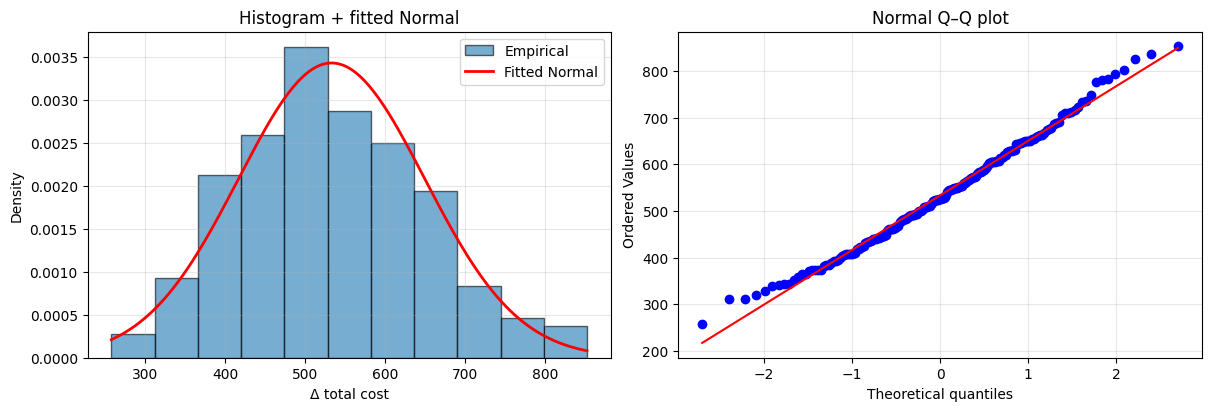

In [17]:
# === Normality diagnostics for paired deltas ===
from inventory.evaluation.deltas import normality_diagnostics
_ = normality_diagnostics(crn_deltas)

---

### ⏱️ Frequentist analysis
In this section, we analyze the policy comparison from a frequentist perspective. Based on the paired deltas, we test whether the observed performance difference is statistically significant under the hypothesis of interest.

Depending on the distribution of the paired differences, we apply an appropriate test and interpret the resulting p-value, test statistic, and confidence interval.

In [18]:
# === Frequentist evaluation of CRN deltas ===
from inventory.evaluation.notebooks.reports import print_frequentist_report_for_crn_deltas

_ = print_frequentist_report_for_crn_deltas(crn_deltas)

=== Frequentist CRN Paired-Delta Analysis (Treatment=B vs Control=A) ===
Objective: cost | Delta convention: treatment-control
Delta definition: Δ = Treatment - Control (B - A)
Direction: B better than A ⇔ Δ < 0 | Win-rate rule: B better ⇔ Δ < 0
Claim: B better than A (one-sided, pre-specified)
Alternative used: less | alpha=0.050

--- Hypotheses ---
H0: E[Δ] = 0  (no average difference)
H1: E[Δ] < 0  (B better than A, because B better ⇔ Δ < 0)

--- Descriptives (deltas) ---
n=200 | mean=533.1670 | median=525.4450 | std=116.4724 | dz=4.5776
min=257.8600 | max=852.2700
win rate (B beats A)=0.0000 (wins=0, losses=200, ties=0)

--- Normality check (Shapiro on deltas) ---
stat=0.9901 | p=0.1863 | reject@0.050=False

--- Hypothesis tests ---
Paired t-test (Δ vs 0): t=64.7374 (df=199) | p=1.0000 | CI(mean)=[516.9262, 549.4077]
Wilcoxon: W=2.01e+04 | p=1.0000
Sign test: p=1.0000 | n_eff=200 (zeros ignored)
Permutation (sign-flip mean): p=1.0000 (n_perm=20000)

--- Paired bootstrap uncertainty

### 🔬 Insights

***Frequentist Analysis***

- **Hypothesis**: Here, we formulate the frequentist null and alternative hypotheses for the paired policy comparison.

- **Results**: Here, we report the main outputs of the frequentist test, including the test statistic, p-value, and confidence interval.

- **Interpretation**: Here, we interpret the frequentist results and relate them back to the original policy question.

---

### 🎰 Bayesian analysis
In this section, we examine the policy comparison from a Bayesian perspective. Based on the paired deltas, we estimate the probability that one policy outperforms the other and quantify the uncertainty around the effect. the goal is to assess how credible the observed performance advantage is, how large the effect is likely to be, and what this implies for our decision-making problem.

This complements the frequentist view by focusing on credible effect sizes and probabilistic interpretation rather than statistical significance alone.

In [19]:
# === Bayesian evaluation of CRN deltas ===
from inventory.evaluation.notebooks.reports import print_bayesian_report_for_crn_deltas

print_bayesian_report_for_crn_deltas(
    crn_deltas,
    better="lower",
    deltas_are="B_minus_A",
    random_state=0,
    n_draws=200_000,
    cred_level=0.95,
    delta=0.0,
    rope=0.0,
    mode="full",
)

Decision @ 0.95: NO PASS —   P(E[B-A] <= -0) = 0.000
----------------------------------------------------
Bayesian Policy Comparison (paired CRN, episode TOTAL cost)
n episodes: 200
Interpretation: deltas = B - A

Data summary (deltas = B-A):
  sample mean:  533.167
  sample sd  :  116.472
  min / max  :  257.86 /  852.27

Posterior on mean treatment effect (E[B-A]):
  95.0% CrI: [ 517.265,  549.363]
  P(E[B-A] < 0): 0.000
  P(E[B-A] <= -0): 0.000

Verdict:
  Weak/insufficient evidence: P(E[B-A] <= -0) = 0.000


### 🔬 Insights

***Bayesian Analysis***

- **Hypothesis**: Here, we formulate the Bayesian hypothesis of interest for the paired policy comparison.
- **Results**: Here, we summarize the posterior results, including credible intervals and the probability that one policy outperforms the other.
- **Interpretation**: Here, we interpret the Bayesian findings and discuss what they imply for the policy comparison.

---

## 🚀 Appendix C: Further variatons

In this section, you can explore further variations of the candidate policy to generate additional insights.

To proceed, copy the **Policy Definition** section, modify the policy as needed, and rerun the evaluation pipeline. If appropriate, you may also use the appendices to support a deeper analysis of the new variation.

### 🤖 🪄Additional Policy definition

In [20]:
# === Copy and adjust 🤖 🪄Additional Policy definition section here ===

### 🪄Additional Experiment run and Strict-CRN policy evaluation

In [21]:
# === Copy and run 🤖 🪄Additional Experiment run and Strict-CRN policy evaluationsection here ===

### 🏎️ Additional Appendix A: Dynamics of the system under policy regimes section

In [22]:
# === Copy and run 🏎️ Appendix A: Dynamics of the system under policy regimes section here ===

### 🔍 Additional Appendix B: Statistical validation section 

In [23]:
# === Copy and run 🔍 Appendix B: Statistical validation section here ===

### 🔬 Additional Insights

In [24]:
# === Insert 🔬 Additional Insights here ===

---

---

## 🔮 Appendix D: Information model definition

In this section, we specify (if relevant) which information model the policy uses to anticipate future demand. We begin by formulating the forecasting task and explaining why a forecast is needed in this setting. We then describe the training data, including the features and labels used for learning.

Next, we train the selected forecaster variants and conclude with a short sanity check to ensure that the resulting predictions are reasonable before they are embedded into the policy.

In [25]:
# === Forecasting task ===
# - what is being predicted?
# - why is forecasting needed here?

In [26]:
# === Forecaster training data & training ===
# - where the data comes from
# - short explanation of features and labels

# - fit constant / linear / GBDT / MLP / quantile forecaster

In [27]:
# === Forecaster sanity check ===
# - small plot or a few example predictions

---

## 👨‍🏫 Lecturer Notes

The AR(1) version is now implemented for the multi-regime ML forecaster. It augments the regime-transition features with the most recent realized demand and rolls that lag forward recursively across the forecast horizon. This is a useful next step beyond the pure regime-aware model, although in the current exogenous setup the regime variables already explain most of the predictable structure, so AR(1) may change forecasts more than it changes final policy quality.

I’m checking how forecast `info` is threaded through the policy call path, because autoregression only makes sense if the forecaster can see recent realized demand at decision time.

Retrieving Notebook summary.

Searched for regex `forecast_mean_path\(|last_demand|info\[|OrderMilpCfaPolicy|forecaster\.forecast_mean_path` (`**/src/**/*.py`), 98 results

Read [](file:///Users/christopherlisson/Projects/sdam_introduction/src/inventory/policies/cfa_milp.py#1-1), lines 1 to 260

I confirmed the policy already passes `info` into the forecaster, and the simulator currently injects `last_demand` each step. I’m reading that path so I can tell you whether a true autoregressive design needs a new adapter only, or also a small change in what the simulator exposes.

Read [](file:///Users/christopherlisson/Projects/sdam_introduction/src/inventory/core/dynamics.py#140-140), lines 140 to 190

Read [](file:///Users/christopherlisson/Projects/sdam_introduction/src/inventory/evaluation/info.py)

Read [](file:///Users/christopherlisson/Projects/sdam_introduction/src/inventory/forecasters/base.py)

Yes, but I would not overwrite the current `MultiRegimeFeatureAdapter`. I would add a new adapter for the autoregressive case.

The reason is that the current split is clean:
- ml.py `MultiRegimeFeatureAdapter` encodes only exogenous regime information.
- ml.py `MlRegimeDemandForecaster` learns from those regime features.
- dynamics.py the simulator already passes `last_demand` into `info`, so an AR(1) design is already possible without touching the environment.

What I would build is this:

1. A new adapter, for example `MultiRegimeAutoregressiveFeatureAdapter`.
2. Possibly a small extension or sibling forecaster, because the current regime forecaster calls `adapter.features_path(state, t, H)` without using `info`, and autoregression needs lagged observed demand from `info`.

The feature idea is straightforward. Instead of using only regime-transition probabilities, use

```python
phi_t = [
    1,
    regime_features...,
    last_demand,
    last_demand_2,
    ...,
    last_demand_p,
]
```

where:
- `regime_features` come from the current multi-regime adapter logic
- `last_demand`, `last_demand_2`, ... are lagged realized demands

So conceptually you would train

```python
X_t = [regime info at time t, demand lags up to time t]
y_t = D_{t+1}
```

That gives the model both:
- structural information from season/day/weather transitions
- local serial dependence from recent realized demand

The important design choice is this:

For AR(1):
- no simulator change is needed, because `last_demand` is already available in `info`
- you can build a new forecaster that reads `info["last_demand"]` and appends it to the regime features

For AR(p) with `p > 1`:
- yes, I would extend the interface a bit
- the cleanest option is to have the simulator pass `last_demands` as a short vector in `info`
- I would prefer that over storing hidden mutable history inside the forecaster, because the current policy/forecaster interface is basically stateless and reproducible

So the full answer is: yes, for a proper autoregressive multi-regime model I would build a new adapter, but adapter alone is not enough. I would also make the forecaster consume lagged-demand info.

A pragmatic design would look like this:

```python
class MultiRegimeAutoregressiveFeatureAdapter:
    def __init__(self, exog, n_lags=1):
        self.exog = exog
        self.n_lags = int(n_lags)

    def base_features(self, state, t):
        # reuse current MultiRegimeFeatureAdapter logic
        ...

    def _lag_vector(self, info):
        # read last_demand or last_demands from info
        ...

    def features(self, state, t, info=None):
        return np.concatenate([self.base_features(state, t), self._lag_vector(info)])

    def generate_dataset(self, n_samples, seed, t_start=0):
        # simulate a demand path from exogenous model
        # build rows with regime features + realized lagged demands
        ...
```

and then the forecaster side would need recursive multi-step prediction:

```python
def forecast_mean_path(self, state, t, H, info=None):
    lags = initial_lags_from_info(info)
    out = []
    for k in range(H):
        xk = adapter.features_with_lags(state, t + k, lags)
        mu_k = model.predict(xk)
        out.append(mu_k)
        lags = shift_lags_and_append(mu_k)
    return np.array(out)
```

That recursion matters. At forecast time you only know the real lagged demand at the first step. For later steps in the horizon, you have to feed the model’s own predicted demand back in as the next lag. That is why this is more than just swapping adapters.

In short:

- If you only want AR(1): build a new autoregressive multi-regime forecaster using the already available `last_demand`.
- If you want AR(p): yes, build a new adapter and extend `info` to carry `last_demands`.
- I would keep the current `MultiRegimeFeatureAdapter` unchanged and add a separate autoregressive version rather than folding both behaviors into one class.

If you want, I can implement the minimal AR(1) version now. That is the smallest useful next step and does not require changing the simulator.

One caveat matters: in your current multi-regime exogenous model, most predictable structure already comes from the observed regime state itself, so AR(1) is implemented correctly but may not improve final policy quality much. It will mostly matter if recent realized demand contains extra information beyond the current regime features.

Natural next steps:

Rerun the experiment evaluation cell in EIMR_040_OrderMilpCfaPolicy_vs_baseline..ipynb to see whether the AR(1) candidate_var changes total-cost results.
If you want AR(p) next, I can extend the info payload from a single last_demand to a bounded last_demands history and generalize this adapter cleanly.